In [ ]:
#based on age or estimated salary; purchased or not 

# 400 rows, 5 columns
# step:
# data preprocessing - spliting - age & est  = x and purchased = y |  load csv, 
# 2. row split - randomly picked 25% data for testing and 75% for training and labeling them. x_train and y_train
# 3. testing
# 4. create desicion tree - x_train and y_train for testing with ONLY x_test and then validiating it by testing data isng x_test only and predict y_test
# 5. then compare prediction


# steps (Common approach):

# 1. colum split = feature required
# 2. row split 
# 3. standard scalar

In [45]:
import pandas as ps
import numpy as nm
import matplotlib.pyplot as plt

In [46]:
df = ps.read_csv("../data/Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [50]:
print("InDependent variable, X:")
x = df.iloc[:, [2, 3]].values                 #[:, :-1] --- all column; not last one
print(x)

print("Dependent variable, Y:")
y = df.iloc[:, 4].values
print(y)

InDependent variable, X:
[[    19  19000]
 [    35  20000]
 [    26  43000]
 [    27  57000]
 [    19  76000]
 [    27  58000]
 [    27  84000]
 [    32 150000]
 [    25  33000]
 [    35  65000]
 [    26  80000]
 [    26  52000]
 [    20  86000]
 [    32  18000]
 [    18  82000]
 [    29  80000]
 [    47  25000]
 [    45  26000]
 [    46  28000]
 [    48  29000]
 [    45  22000]
 [    47  49000]
 [    48  41000]
 [    45  22000]
 [    46  23000]
 [    47  20000]
 [    49  28000]
 [    47  30000]
 [    29  43000]
 [    31  18000]
 [    31  74000]
 [    27 137000]
 [    21  16000]
 [    28  44000]
 [    27  90000]
 [    35  27000]
 [    33  28000]
 [    30  49000]
 [    26  72000]
 [    27  31000]
 [    27  17000]
 [    33  51000]
 [    35 108000]
 [    30  15000]
 [    28  84000]
 [    23  20000]
 [    25  79000]
 [    27  54000]
 [    30 135000]
 [    31  89000]
 [    24  32000]
 [    18  44000]
 [    29  83000]
 [    35  23000]
 [    27  58000]
 [    24  55000]
 [    23  48000]
 [    

In [51]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(
    x,y,
    test_size=0.25,
    random_state=45
)


In [53]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
x_train = sc_x.fit_transform(x_train) 
x_test=sc_x.transform(x_test)

print(x_test)

[[ 1.41453728  0.58904039]
 [ 1.51387276  0.06432609]
 [ 0.22251148  0.06432609]
 [ 1.91121469 -1.07255491]
 [ 0.22251148 -0.25633266]
 [-1.86353366 -1.42236445]
 [-0.57217238  0.47243721]
 [-0.27416593  0.06432609]
 [-1.26752076  0.50158801]
 [ 2.10988566 -1.18915809]
 [-0.87017883  0.15177847]
 [ 0.7191889   0.26838165]
 [-1.36685625 -1.10170571]
 [ 1.81187921 -0.28548345]
 [ 0.123176   -0.81019776]
 [-1.86353366  0.18092927]
 [-1.16818528  0.06432609]
 [ 0.91785986 -1.45151524]
 [-1.96286914 -0.51868981]
 [-1.76419818 -1.36406286]
 [-0.07549497  0.26838165]
 [ 1.71254373  1.60931821]
 [-0.27416593 -0.43123742]
 [ 0.22251148  0.15177847]
 [-0.87017883 -0.25633266]
 [-1.96286914 -0.05227709]
 [-0.87017883  2.27978649]
 [-1.26752076  0.58904039]
 [ 0.91785986 -1.36406286]
 [ 0.02384052 -0.25633266]
 [ 0.52051793  1.23035788]
 [ 0.22251148 -0.37293583]
 [ 2.10988566 -0.81019776]
 [-1.16818528  1.40526265]
 [-0.27416593  0.15177847]
 [ 0.7191889  -1.39321365]
 [-1.16818528  0.29753245]
 

In [54]:
#start using Decision Tree

#fitting decision tree classification to the training set
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion='entropy', random_state=0)

#We use entropy parameter above; there is GINI approach too
# classifier = DecisionTreeClassifier(criterion='gini', random_state=0)


#it train the data
classifier.fit(x_train,y_train)



,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [57]:
# Prediciting the TEST set results

y_pred = classifier.predict(x_test)         #here we give X_testing data and prediciting Y data

print("Actual: ",y_test)
print("Predicted: ",y_pred)

Actual:  [1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 0 0 0 0 1 0
 1 0 1 0 1 1 1 0 1 1 1 0 0 0 0 1 1 0 0 1 0 1 1 0 0 1 0 0 1 0 0 0 1 0 0 0 0
 1 1 0 0 1 1 0 1 0 0 0 0 0 1 0 1 1 0 1 0 0 0 1 0 0 0]
Predicted:  [1 1 1 1 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 1 1 0 1 0
 1 0 1 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0 1 0 0 0 0
 1 0 1 0 1 1 0 1 1 0 0 0 0 1 0 0 1 0 1 0 0 0 1 0 0 0]


In [62]:
#Making confusion matrix

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print("True Pos", cm[0][0])
print("True Neg", cm[0][1])
print("False Pos", cm[1][0])
print("False Neg", cm[1][1])


True Pos 56
True Neg 6
False Pos 10
False Neg 28


In [65]:
#finding Accuracy of matrix

accuracy = (cm[0][0]  + cm[1][1]) / (cm[0][0]  + cm[1][1] + cm[1][0] + cm[0][1])
print("Accuracy - ", accuracy)

Accuracy -  0.84


In [ ]:
# # taks = (0.2, 0.25, 0.3)       testing data with different test split ratio
# do for gini

# do for this for all above and find highest accuracy for both gini and entropy

In [67]:
#find accuracy with inbuilt 

from sklearn import metrics
predicition = metrics.accuracy_score(y_test, y_pred)

print("Accuracy score: ", predicition * 100, "%")

Accuracy score:  84.0 %


In [69]:
#it return complete report of it 

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88        62
           1       0.82      0.74      0.78        38

    accuracy                           0.84       100
   macro avg       0.84      0.82      0.83       100
weighted avg       0.84      0.84      0.84       100



In [79]:
new = nm.array([[29,80000]])

new_scl = sc_x.transform(new)

predicition = classifier.predict(new_scl)

if predicition[0] == 1:
    print("Predicted to Purchased")
else:
    print("Not Predicted to Purchased")

Predicted to Purchased


[Text(0.4883720930232558, 0.9583333333333334, 'x[0] <= 0.62\nentropy = 0.934\nsamples = 300\nvalue = [195, 105]'),
 Text(0.27325581395348836, 0.875, 'x[1] <= 0.604\nentropy = 0.646\nsamples = 218\nvalue = [182, 36]'),
 Text(0.3808139534883721, 0.9166666666666667, 'True  '),
 Text(0.10465116279069768, 0.7916666666666666, 'x[0] <= -0.125\nentropy = 0.182\nsamples = 182\nvalue = [177, 5]'),
 Text(0.08139534883720931, 0.7083333333333334, 'entropy = 0.0\nsamples = 122\nvalue = [122, 0]'),
 Text(0.12790697674418605, 0.7083333333333334, 'x[1] <= 0.021\nentropy = 0.414\nsamples = 60\nvalue = [55, 5]'),
 Text(0.10465116279069768, 0.625, 'entropy = 0.0\nsamples = 31\nvalue = [31, 0]'),
 Text(0.1511627906976744, 0.625, 'x[1] <= 0.4\nentropy = 0.663\nsamples = 29\nvalue = [24, 5]'),
 Text(0.12790697674418605, 0.5416666666666666, 'x[1] <= 0.137\nentropy = 0.592\nsamples = 28\nvalue = [24, 4]'),
 Text(0.046511627906976744, 0.4583333333333333, 'x[0] <= 0.173\nentropy = 0.371\nsamples = 14\nvalue = [1

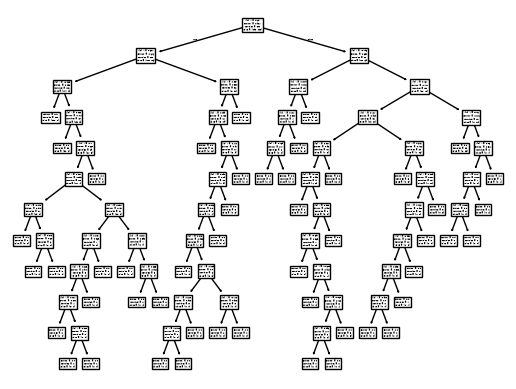

In [75]:
from sklearn import tree

tree.plot_tree(classifier)